C:\Users\domin\juwavelet\juwavelet\transform.py:633: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis, np.newaxis] / (
C:\Users\domin\juwavelet\juwavelet\transform.py:635: RuntimeWarning: divide by zero encountered in divide
  wzs = np.tile(periods[:, np.newaxis, np.newaxis] /
100%|████████████████████████████████████████████████████████████████████████████████| 672/672 [47:05<00:00,  4.21s/it]


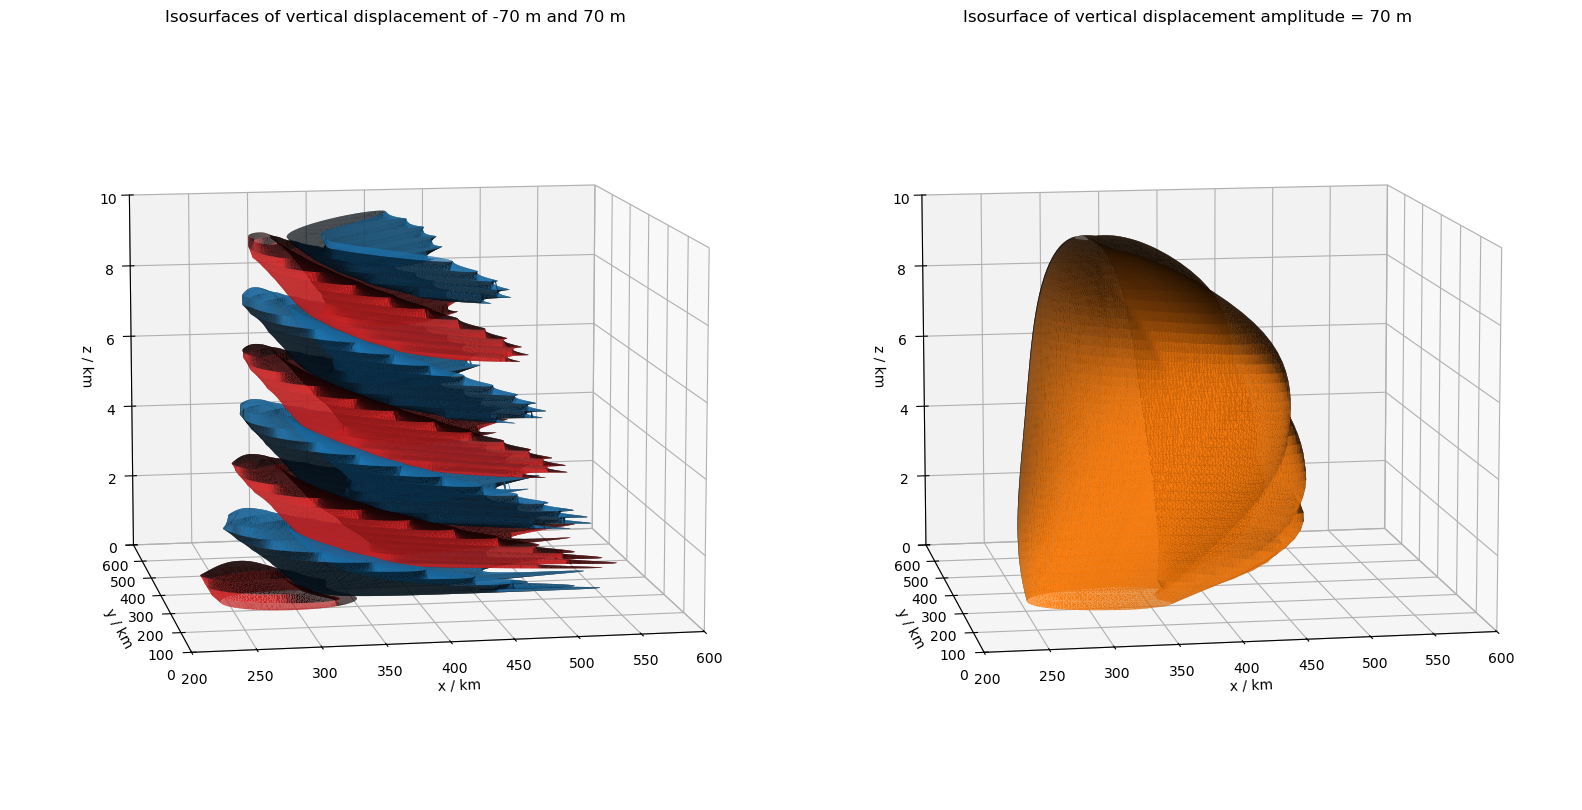

In [2]:
# %matplotlib inline  # uncomment in Jupyter if needed

from juwavelet import transform

import numpy as np
from skimage import measure
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # makes sure 3D projection is registered


def cartesian_to_spherical(normal):
    """Convert a 3D vector to (azimuth, zenith)."""
    x, y, z = normal
    azimuth = np.arctan2(y, x)
    r = np.linalg.norm([x, y, z])
    zenith = np.arcsin(z / r)
    return azimuth, zenith


def spherical_to_cartesian(azimuth, zenith):
    """Convert (azimuth, zenith) back to a unit 3D vector."""
    x = np.cos(zenith) * np.cos(azimuth)
    y = np.cos(zenith) * np.sin(azimuth)
    z = np.sin(zenith)
    return np.array([x, y, z])


def enforce_angles(normals):
    """
    Enforce a consistent 180° choice for normals.
    Azimuth is forced into [0, pi].
    """
    consistent_normals = np.zeros_like(normals)

    for i, normal in enumerate(normals):
        azimuth, zenith = cartesian_to_spherical(normal)

        # Force azimuth into [0, pi]
        if azimuth < 0:
            azimuth += np.pi

        consistent_normals[i] = spherical_to_cartesian(azimuth, zenith)

    return consistent_normals


def get_normals(verts, faces):
    """
    Compute per-face normal vectors.

    Parameters
    ----------
    verts : (Nverts, 3) array
        Vertices of the mesh.
    faces : (Nfaces, 3) array of int
        Indices of the 3 vertices for each triangle.

    Returns
    -------
    normals : (Nfaces, 3) array of float
    """
    normals = np.zeros((faces.shape[0], 3), dtype=float)

    for i, face in enumerate(faces):
        v0 = verts[face[0]]
        v1 = verts[face[1]]
        v2 = verts[face[2]]

        edge1 = v1 - v0
        edge2 = v2 - v0

        normal = np.cross(edge1, edge2)
        norm = np.linalg.norm(normal)
        if norm > 0:
            normal = normal / norm

        normals[i] = normal

    return enforce_angles(normals)


def prepare_facecolor(faces_a, faces_b, color_a, color_b):
    """Build RGBA facecolor array for two sets of faces."""
    rgba_a = mcolors.to_rgba(color_a)
    rgba_b = mcolors.to_rgba(color_b)

    color_array_a = np.tile(rgba_a, (faces_a.shape[0], 1))
    color_array_b = np.tile(rgba_b, (faces_b.shape[0], 1))
    color_array_both = np.vstack((color_array_a, color_array_b))

    return color_array_both


def plot_3D_wave(ax, data_array, iso_values, increments=(1.0, 1.0, 1.0),
                 facecolors=('tab:blue', 'tab:red'), ls=None):
    """
    Plot two isosurfaces from a 3D array on a given Axes3D.

    ax : 3D axes
    data_array : (nx, ny, nz) array
    iso_values : list of two iso levels [v1, v2]
    increments : (dx, dy, dz) for scaling axes
    facecolors : colors for the two isosurfaces
    ls : LightSource for shading, or None
    """
    verts_one, faces_one, _, _ = measure.marching_cubes(data_array, level=iso_values[0])
    verts_two, faces_two, _, _ = measure.marching_cubes(data_array, level=iso_values[1])

    # Combine vertices and faces
    verts_both = np.vstack((verts_one, verts_two))
    faces_both = np.vstack((faces_one, faces_two + verts_one.shape[0]))

    color_array = prepare_facecolor(faces_one, faces_two, facecolors[0], facecolors[1])

    if ls is not None:
        color_copy = color_array.copy()
        normals = get_normals(verts_both, faces_both)
        shading = ls.shade_normals(normals)

        # Apply shading to RGB, keep alpha
        result_rgb = color_copy[:, :3] * shading[:, np.newaxis]
        color_array = np.hstack((result_rgb, color_copy[:, 3:4]))

    dx, dy, dz = increments
    surf = ax.plot_trisurf(
        verts_both[:, 0] * dx,
        verts_both[:, 1] * dy,
        verts_both[:, 2] * dz,
        triangles=faces_both,
        facecolor=color_array,
        shade=False,
    )
    return surf


def eta(r_hat, theta, z_hat, h, nphi=1024):
    """
    Two dimensional hydrostatic wave field, Smith (1980) eq. 20 style.
    r_hat, theta are 2D arrays, z_hat is scalar, h is mountain height.
    """
    phis = np.linspace(0, 2 * np.pi, nphi, endpoint=False)  # (nphi,)
    dphi = 2 * np.pi / nphi

    phis_ = phis[:, None, None]        # (nphi, 1, 1)
    r_hat_ = r_hat[None, :, :]         # (1, nx, ny)
    theta_ = theta[None, :, :]         # (1, nx, ny)

    arg = phis_ - theta_               # (nphi, nx, ny)

    num = np.exp(1j * z_hat / np.cos(phis_))   # (nphi, 1, 1)
    denom = (1 - 1j * r_hat_ * np.cos(arg))**2 # (nphi, nx, ny)

    integrand = num / denom            # (nphi, nx, ny)
    integral = np.sum(integrand, axis=0) * dphi  # (nx, ny)

    return h / (2 * np.pi) * integral


# ----------------- build the 3D wavefield -----------------
h, a = 1000.0, 25000.0  # mountain height (m), horizontal scale (m)
U, N = 10.0, 0.02       # wind speed (m/s), BV frequency (1/s)

nx, ny, nz = 300, 250, 40   # you can reduce these if it is too slow
dx = dy = 2000.0
dz = 250.0

x = np.linspace(-nx * dx / 2, nx * dx / 2, nx)
y = np.linspace(-ny * dy / 2, ny * dy / 2, ny)
X, Y = np.meshgrid(x, y, indexing='ij')
z = np.linspace(0, nz * dz, nz)

R = np.hypot(X, Y)
r_hat = R / a
Theta = np.arctan2(Y, X)

wavefield = np.full((len(x), len(y), len(z)), np.nan, dtype=complex)
for zz in range(len(z)):
    z_hat = z[zz] * N / U
    wavefield[:, :, zz] = eta(r_hat, Theta, z_hat, h, nphi=2048)

# For plotting we only need the real part
wavefield_real = wavefield.real


# ----------------- 3D CWT -----------------
s0 = 2 * dx
s1 = nx * dz
dj = 1.0 / 4.0
jt = 6
jp = 7
js = int(1 / dj * np.log2(s1 / s0))

result = transform.decompose3d(
    wavefield_real,
    dx, dy, dz,
    s0, dj, js, jt, jp,
    aspect=10,
    nxpad=None, nypad=None, nzpad=None,
    opts={'param': 4, 'threshold': 0},
    mode="scaled",
    dtype=np.complex64,
)

# Vertical displacement amplitude
vol = np.max(np.abs(result['decomposition']), axis=(0, 1, 2))  # (nx, ny, nz)
iso_val = 70.0

verts_amp, faces_amp, _, _ = measure.marching_cubes(vol, level=iso_val)
amp_normals = get_normals(verts_amp, faces_amp)

# ----------------- plotting -----------------
ls = LightSource(azdeg=60, altdeg=45)

fig = plt.figure(figsize=(16, 8))

# Left panel: two isosurfaces of the signal
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_3D_wave(
    ax1,
    wavefield_real,
    iso_values=[-70.0, 70.0],
    increments=(dx * 1e-3, dy * 1e-3, dz * 1e-3),
    ls=ls,
)
ax1.set_xlabel('x / km')
ax1.set_ylabel('y / km')
ax1.set_zlabel('z / km')
ax1.set_xlim([200, 600])
ax1.set_ylim([0, 600])
ax1.set_zlim([0, 10])
ax1.view_init(elev=10, azim=-100)
ax1.set_title(r'Isosurfaces of vertical displacement of -70 m and 70 m')

# Right panel: amplitude isosurface
shading = ls.shade_normals(amp_normals)
rgba = mcolors.to_rgba('tab:orange')
color_array = np.tile(rgba, (faces_amp.shape[0], 1))
result_rgb = color_array[:, :3] * shading[:, np.newaxis]
color_array_amp = np.hstack((result_rgb, color_array[:, 3:4]))

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_trisurf(
    verts_amp[:, 0] * dx * 1e-3,
    verts_amp[:, 1] * dy * 1e-3,
    verts_amp[:, 2] * dz * 1e-3,
    triangles=faces_amp,
    facecolor=color_array_amp,
    shade=False,
)
ax2.set_xlabel('x / km')
ax2.set_ylabel('y / km')
ax2.set_zlabel('z / km')
ax2.set_xlim([200, 600])
ax2.set_ylim([0, 600])
ax2.set_zlim([0, 10])
ax2.view_init(elev=10, azim=-100)
ax2.set_title(r'Isosurface of vertical displacement amplitude = 70 m')

plt.tight_layout()

# Save and show
plt.savefig('3d_decomposition_example.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")
plt.savefig('3d_decomposition_example.pdf', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")
plt.show()
